In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wedataset/wdataset/weed/623.jpg
/kaggle/input/wedataset/wdataset/weed/764.jpg
/kaggle/input/wedataset/wdataset/weed/771.jpg
/kaggle/input/wedataset/wdataset/weed/208.jpg
/kaggle/input/wedataset/wdataset/weed/820.jpg
/kaggle/input/wedataset/wdataset/weed/473.jpg
/kaggle/input/wedataset/wdataset/weed/333.jpg
/kaggle/input/wedataset/wdataset/weed/537.jpg
/kaggle/input/wedataset/wdataset/weed/45.jpg
/kaggle/input/wedataset/wdataset/weed/369.jpg
/kaggle/input/wedataset/wdataset/weed/56.jpg
/kaggle/input/wedataset/wdataset/weed/654.jpg
/kaggle/input/wedataset/wdataset/weed/89.jpg
/kaggle/input/wedataset/wdataset/weed/20.jpg
/kaggle/input/wedataset/wdataset/weed/275.jpg
/kaggle/input/wedataset/wdataset/weed/785.jpg
/kaggle/input/wedataset/wdataset/weed/212.jpg
/kaggle/input/wedataset/wdataset/weed/239.jpg
/kaggle/input/wedataset/wdataset/weed/792.jpg
/kaggle/input/wedataset/wdataset/weed/58.jpg
/kaggle/input/wedataset/wdataset/weed/150.jpg
/kaggle/input/wedataset/wdataset/weed/6

In [5]:
import os
print(os.listdir('/kaggle/input/wedataset/wdataset'))


['weed', 'wheat']


Number of Weed Images: 1000
Number of Wheat Images: 1000
Displaying sample Weed images:


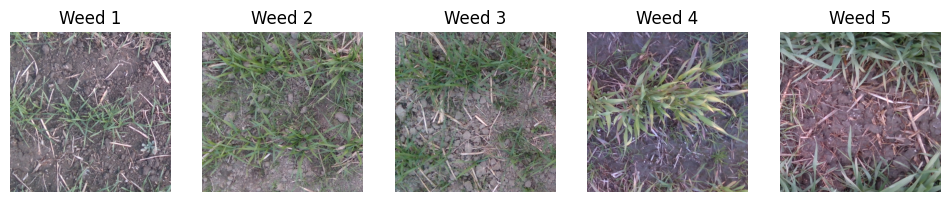

Displaying sample Wheat images:


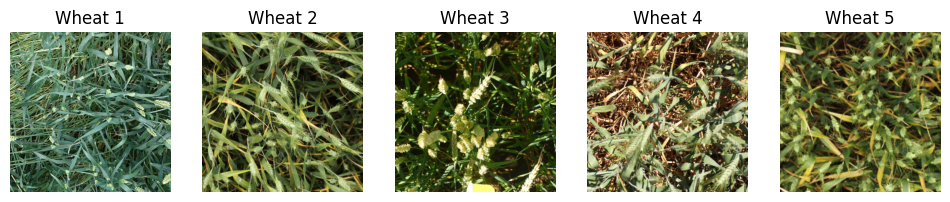

Displaying a batch of augmented images:


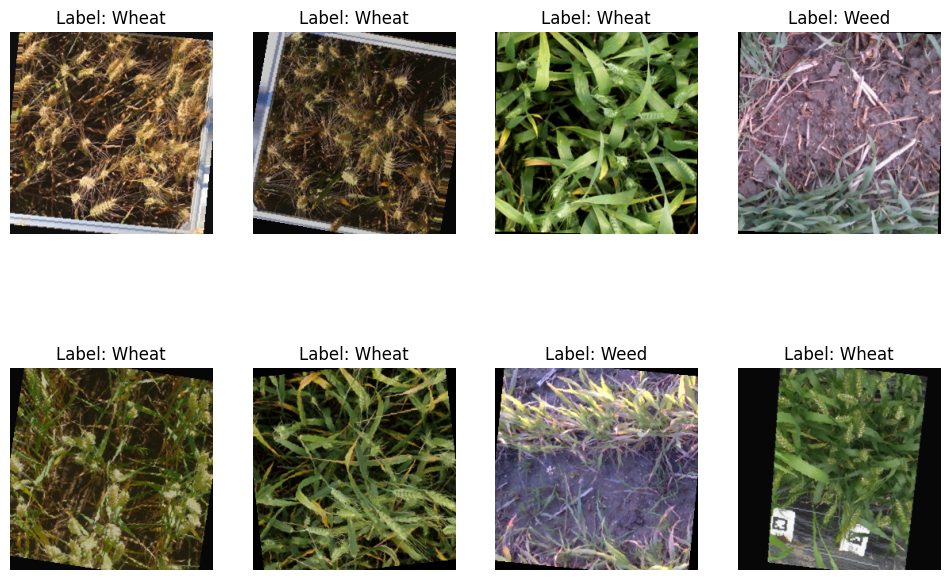

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torch
from torch.utils.data import Dataset, DataLoader

# Define dataset paths 
BASE_PATH = '/kaggle/input/wedataset/wdataset'
WEED_PATH = os.path.join(BASE_PATH, 'weed')
WHEAT_PATH = os.path.join(BASE_PATH, 'wheat')

# ================================
# EDA: Explore Dataset Information
# ================================

def dataset_summary():
    """
    Print summary of dataset and plot sample images.
    """
    # Check folder existence
    if not os.path.exists(WEED_PATH) or not os.path.exists(WHEAT_PATH):
        print("Dataset directories not found. Please check paths!")
        return
    
    # Count images in each folder
    weed_images = os.listdir(WEED_PATH)
    wheat_images = os.listdir(WHEAT_PATH)
    print(f"Number of Weed Images: {len(weed_images)}")
    print(f"Number of Wheat Images: {len(wheat_images)}")

    # Display random sample images
    def display_images(folder_path, title, num_images=5):
        plt.figure(figsize=(12, 6))
        for i, img_file in enumerate(os.listdir(folder_path)[:num_images]):
            img = Image.open(os.path.join(folder_path, img_file))
            plt.subplot(1, num_images, i + 1)
            plt.imshow(img)
            plt.title(f"{title} {i+1}")
            plt.axis('off')
        plt.show()

    print("Displaying sample Weed images:")
    display_images(WEED_PATH, "Weed")

    print("Displaying sample Wheat images:")
    display_images(WHEAT_PATH, "Wheat")

dataset_summary()

# ===========================================
# Custom Dataset Class (With Resizing)
# ===========================================
class WeedWheatDataset(Dataset):
    def __init__(self, weed_path, wheat_path, transform=None):
        self.weed_path = weed_path
        self.wheat_path = wheat_path
        self.transform = transform

        # Collect file paths
        self.image_paths = [(os.path.join(weed_path, img), 0) for img in os.listdir(weed_path)]
        self.image_paths += [(os.path.join(wheat_path, img), 1) for img in os.listdir(wheat_path)]
    
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path, label = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# ===========================================
# Data Augmentation (With Resizing)
# ===========================================
transform_augment = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize all images to 256x256
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor()
])

# ===========================================
# Load Dataset
# ===========================================
dataset = WeedWheatDataset(WEED_PATH, WHEAT_PATH, transform=transform_augment)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# ===========================================
# Visualize Augmented Images
# ===========================================
def visualize_augmented_images(dataloader):
    """
    Display a batch of augmented images.
    """
    images, labels = next(iter(dataloader))
    plt.figure(figsize=(12, 8))
    for i in range(len(images)):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {'Weed' if labels[i] == 0 else 'Wheat'}")
        plt.axis('off')
    plt.show()

print("Displaying a batch of augmented images:")
visualize_augmented_images(dataloader)


In [8]:
def count_images_in_dataset(dataset):
    """
    Count the total number of images in the dataset.
    """
    weed_count = sum(1 for path, label in dataset.image_paths if label == 0)
    wheat_count = sum(1 for path, label in dataset.image_paths if label == 1)
    print(f"Total Images in Dataset: {len(dataset)}")
    print(f" - Weed Images: {weed_count}")
    print(f" - Wheat Images: {wheat_count}")

count_images_in_dataset(dataset)


Total Images in Dataset: 2000
 - Weed Images: 1000
 - Wheat Images: 1000
